## 0. Imports & Helper Functions

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100


def mape_safe(y_true, y_pred, eps=1.0):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true >= eps
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def evaluate(y_true, y_pred, label=""):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "label": label,
        "N":     len(y_true),
        "MAE":   round(mean_absolute_error(y_true, y_pred), 2),
        "RMSE":  round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        "wMAPE": round(wape(y_true, y_pred), 2),
        "MAPE":  round(mape_safe(y_true, y_pred), 2),
        "Bias":  round(float(np.mean(y_pred - y_true)), 2),
        "R2":    round(r2_score(y_true, y_pred), 4),
    }



## 1. Load Data

In [2]:
df = pd.read_csv("features_final.csv")

target_col = "sku_sold"
date_col   = "week_start"

df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(["product_id", date_col]).reset_index(drop=True)
df["product_id"] = df["product_id"].astype("category")

print(f"Loaded  : {len(df):,} rows | {df['product_id'].nunique()} products")
print(f"Period  : {df[date_col].min().date()} → {df[date_col].max().date()}")
print(f"\nTarget distribution (sku_sold):")
print(df[target_col].describe().round(1).to_string())

df.head()


Loaded  : 12,667 rows | 114 products
Period  : 2018-02-19 → 2021-12-20

Target distribution (sku_sold):
count    12667.0
mean        52.7
std        107.8
min          0.0
25%          6.0
50%         17.0
75%         49.0
max       1342.0


,product_id,week,sku_sold,week_start,year,temp_mean,temp_min,temp_max,precip_sum,sunshine_sum,...,week_sin,week_cos,lag_1,lag_2,lag_4,lag_8,rolling_mean_4,rolling_std_4,rolling_mean_8,rolling_std_8
0,2,17,329,2018-04-23,2018,11.285714,3.2,16.6,30.6,29.6,...,0.885456,-0.464723,171.0,798.0,217.0,344.0,367.75,290.630780,363.875,203.750855
1,2,18,173,2018-04-30,2018,11.785714,1.8,25.8,36.6,75.8,...,0.822984,-0.568065,329.0,171.0,285.0,369.0,395.75,276.308252,362.000,204.028709
2,2,19,171,2018-05-07,2018,15.642857,2.5,26.6,4.1,67.0,...,0.748511,-0.663123,173.0,329.0,798.0,499.0,367.75,296.228937,337.500,214.564010
3,2,20,57,2018-05-14,2018,14.557143,4.7,25.8,0.1,58.5,...,0.663123,-0.748511,171.0,173.0,171.0,228.0,211.00,78.672316,296.500,210.596432
4,2,21,171,2018-05-21,2018,19.785714,9.1,29.0,4.8,46.5,...,0.568065,-0.822984,57.0,171.0,329.0,217.0,182.50,111.706461,275.125,226.611333


## 2. Feature Configuration


In [3]:
FEATURE_GROUPS = {
    "Recent sales history": [
        "lag_1", "lag_2", "lag_4", "lag_8",
        "rolling_mean_4", "rolling_mean_8",
        "rolling_std_4",  "rolling_std_8",
    ],
    "Product identity": ["product_id"],
    "Calendar / seasonality": [
        "year", "week", "week_of_year", "month",
        "week_sin", "week_cos", "month_sin", "month_cos",
    ],
    "Holiday effects": [
        "hol_easter", "hol_kings_day", "hol_pentecost", "hol_ascension",
        "hol_christmas", "hol_liberation_day", "hol_new_year",
        "has_holiday", "min_days_to_holiday",
    ],
    "Weather": [
        "temp_mean", "temp_min", "temp_max", "temp_anomaly",
        "precip_sum", "sunshine_sum", "heavy_rain",
    ],
    "Ordering cycle": ["is_month_start", "is_month_end"],
}

drop_cols = [target_col, date_col]
cat_cols  = ["product_id"]

n_features = len([c for c in df.columns if c not in drop_cols])
print(f"Total features that will be used in training: {n_features}")


Total features that will be used in training: 35


## 3. Train / Test Split

In [4]:
train_df = df[df["year"] < 2021].copy()
test_df  = df[df["year"] == 2021].copy()

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target_col]

X_test  = test_df.drop(columns=drop_cols)
y_test  = test_df[target_col]

FEATURE_COLS = X_train.columns.tolist()

print(f"Train : {len(X_train):,} rows | {train_df['year'].min()}–{train_df['year'].max()}")
print(f"Test  : {len(X_test):,} rows  | 2021 (full holdout year)")
print(f"Test share : {len(X_test)/len(df)*100:.1f}% of all data")
print(f"Features   : {len(FEATURE_COLS)}")


Train : 9,568 rows | 2018–2020
Test  : 3,099 rows  | 2021 (full holdout year)
Test share : 24.5% of all data
Features   : 35


## 4. Train Final Model


In [5]:
model = lgb.LGBMRegressor(
    objective        = "regression",
    metric           = "mae",         # early-stopping on MAE, not RMSE
    n_estimators     = 1000,          # upper bound; early stopping decides actual count
    learning_rate    = 0.05,
    num_leaves       = 63,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_samples= 20,
    reg_alpha        = 0.1,
    reg_lambda       = 0.1,
    random_state     = 42,
    verbose          = -1,
)

model.fit(
    X_train, y_train,
    eval_set            = [(X_train, y_train), (X_test, y_test)],
    eval_names          = ["train", "test"],
    callbacks           = [
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100),
    ],
    categorical_feature = cat_cols,
)

print(f"Best iteration      : {model.best_iteration_}")
print(f"Train MAE (best)    : {model.best_score_['train']['l1']:.4f}")
print(f"Test  MAE (best)    : {model.best_score_['test']['l1']:.4f}")


[100]	train's l1: 14.3613	test's l1: 27.9033
Best iteration      : 76
Train MAE (best)    : 15.7225
Test  MAE (best)    : 27.8444


## 5. Predictions & Evaluation

In [6]:
y_pred_train = np.maximum(model.predict(X_train), 0)
y_pred_test  = np.maximum(model.predict(X_test),  0)

y_naive = test_df["lag_1"].values

results = [
    evaluate(y_train.values, y_pred_train, "LightGBM — Train"),
    evaluate(y_test.values,  y_pred_test,  "LightGBM — Test"),
    evaluate(y_test.values,  y_naive,      "Naive baseline (lag-1)"),
]

results_df = pd.DataFrame(results).set_index("label")
print("Model Evaluation")
print("=" * 65)
display(results_df[["MAE", "RMSE", "wMAPE", "MAPE", "Bias", "R2"]])


lgbm_mae    = results[1]["MAE"];   naive_mae    = results[2]["MAE"]
lgbm_wmape  = results[1]["wMAPE"]; naive_wmape  = results[2]["wMAPE"]
lgbm_r2     = results[1]["R2"];    naive_r2     = results[2]["R2"]


Model Evaluation


,MAE,RMSE,wMAPE,MAPE,Bias,R2
label,,,,,,
LightGBM — Train,15.72,30.16,31.46,120.10,-0.00,0.9137
LightGBM — Test,27.84,61.06,45.48,128.37,-0.43,0.7491
Naive baseline (lag-1),33.10,73.71,54.06,117.19,0.94,0.6343


## 6. Export Predictions

In [7]:
predictions = test_df[[date_col, "product_id", target_col]].copy()
predictions["predicted_sku_sold"] = y_pred_test
predictions["error"]              = predictions[target_col] - predictions["predicted_sku_sold"]
predictions["absolute_error"]     = predictions["error"].abs()

predictions.to_csv("lightgbm_predictions.csv", index=False)
print(f"Saved lightgbm_predictions.csv — {len(predictions):,} rows")
predictions.head()


Saved lightgbm_predictions.csv — 3,099 rows


,week_start,product_id,sku_sold,predicted_sku_sold,error,absolute_error
67,2021-02-08,2,867,219.053978,647.946022,647.946022
68,2021-02-15,2,404,408.068926,-4.068926,4.068926
69,2021-02-22,2,805,455.469663,349.530337,349.530337
70,2021-03-01,2,285,511.523873,-226.523873,226.523873
71,2021-03-08,2,458,478.633965,-20.633965,20.633965


## 7. Visualisations

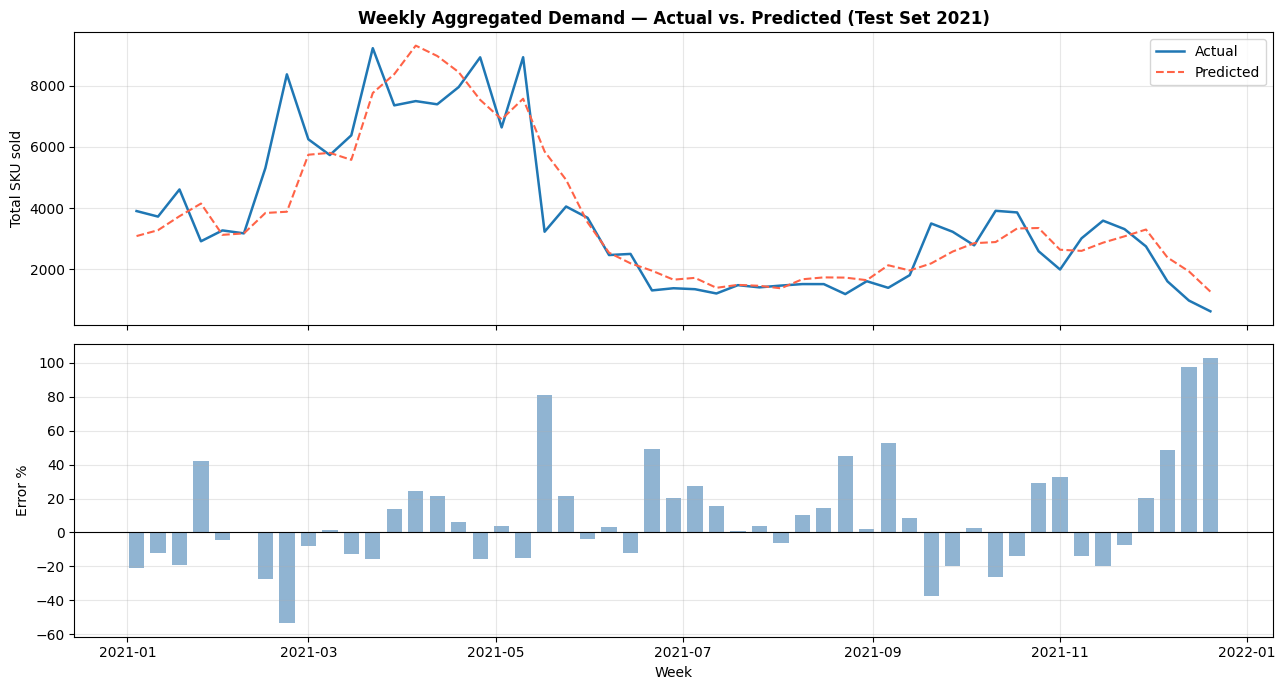

In [8]:
weekly = (
    predictions
    .groupby(date_col)
    .agg(actual=("sku_sold", "sum"), predicted=("predicted_sku_sold", "sum"))
    .reset_index()
)
weekly["error_pct"] = (
    (weekly["predicted"] - weekly["actual"])
    / weekly["actual"].replace(0, np.nan) * 100
)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(weekly[date_col], weekly["actual"],    label="Actual",    linewidth=1.8)
axes[0].plot(weekly[date_col], weekly["predicted"], label="Predicted",
             linewidth=1.5, linestyle="--", color="tomato")
axes[0].set_ylabel("Total SKU sold")
axes[0].set_title("Weekly Aggregated Demand — Actual vs. Predicted (Test Set 2021)",
                  fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].bar(weekly[date_col], weekly["error_pct"], width=5,
            color="steelblue", alpha=0.6)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Error %")
axes[1].set_xlabel("Week")
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig("weekly_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()


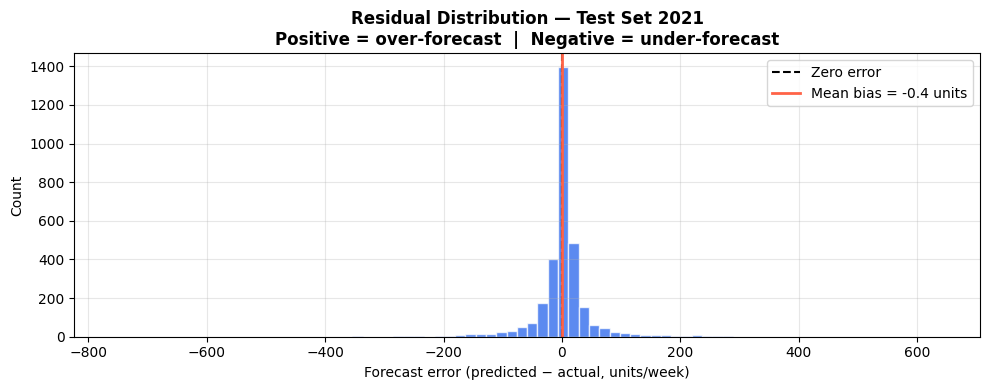

Mean bias   : -0.43 units  (positive = over-forecast)
Std of error: 61.06 units
% predictions within ±10 units: 48.0%
% predictions within ±50 units: 86.2%


In [9]:
residuals = y_pred_test - y_test.values

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(residuals, bins=80, color="#2563EB", alpha=0.75, edgecolor="white")
ax.axvline(0,              color="black",  lw=1.5, ls="--", label="Zero error")
ax.axvline(residuals.mean(), color="tomato", lw=2.0,
           label=f"Mean bias = {residuals.mean():.1f} units")
ax.set_xlabel("Forecast error (predicted − actual, units/week)")
ax.set_ylabel("Count")
ax.set_title("Residual Distribution — Test Set 2021\n"
             "Positive = over-forecast  |  Negative = under-forecast",
             fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("residual_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean bias   : {residuals.mean():+.2f} units  (positive = over-forecast)")
print(f"Std of error: {residuals.std():.2f} units")
print(f"% predictions within ±10 units: "
      f"{(np.abs(residuals) <= 10).mean()*100:.1f}%")
print(f"% predictions within ±50 units: "
      f"{(np.abs(residuals) <= 50).mean()*100:.1f}%")


## 8. SHAP Explanations

In [10]:
explainer    = shap.TreeExplainer(model)
SHAP_SAMPLE_N = min(1000, len(X_test))
shap_idx      = X_test.sample(n=SHAP_SAMPLE_N, random_state=42).index
X_shap        = X_test.loc[shap_idx]

shap_values = explainer(X_shap)


baseline = float(explainer.expected_value)
mean_shap = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=FEATURE_COLS
).sort_values(ascending=False)

print(f"Baseline E[f(x)] (average prediction over training set): {baseline:.2f} units")
print(f"\nTop 10 features by mean |SHAP value|:")
print(mean_shap.head(10).round(3).to_string())


Baseline E[f(x)] (average prediction over training set): 49.98 units

Top 10 features by mean |SHAP value|:
lag_1                  20.984
rolling_mean_4         16.136
product_id             14.124
lag_2                   4.489
week_sin                2.814
week                    2.433
rolling_mean_8          2.121
week_cos                1.719
year                    1.474
min_days_to_holiday     1.472


### Global Feature Importance

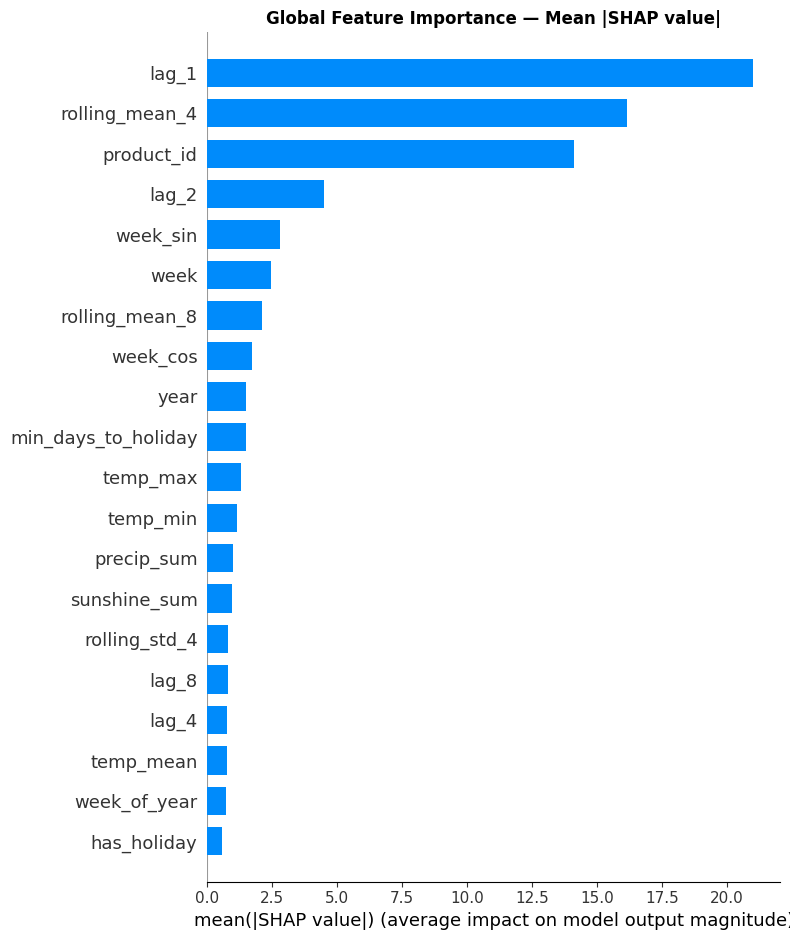

In [11]:
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False, max_display=20)
plt.title("Global Feature Importance — Mean |SHAP value|", fontweight="bold")
plt.tight_layout()
plt.savefig("shap_bar_plot.png", dpi=150, bbox_inches="tight")
plt.show()


###Group-Level Feature Importance

Group-Level SHAP Importance
  Recent sales history                  46.60  ( 59.1%)  █████████████████████████████
  Product identity                      14.12  ( 17.9%)  ████████
  Calendar / seasonality                10.13  ( 12.8%)  ██████
  Weather                                5.56  (  7.1%)  ███
  Holiday effects                        2.38  (  3.0%)  █
  Ordering cycle                         0.06  (  0.1%)  


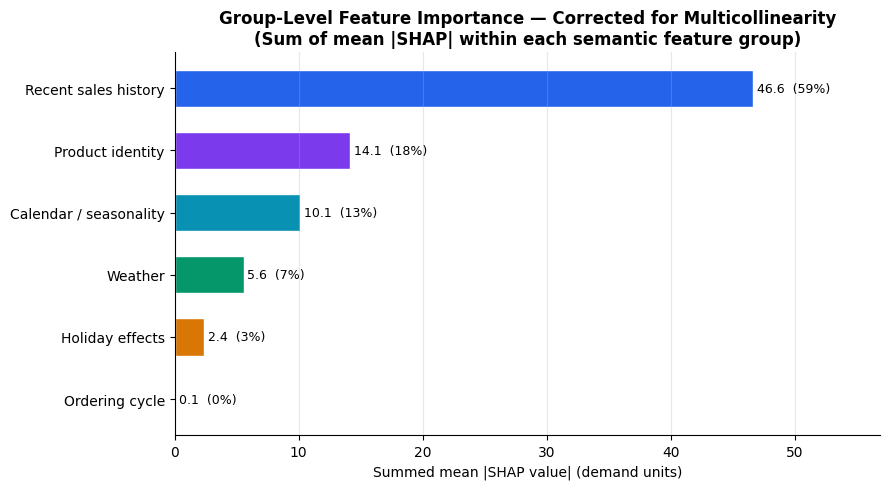

In [12]:
group_shap = {}
for group, feats in FEATURE_GROUPS.items():
    present      = [f for f in feats if f in FEATURE_COLS]
    feat_indices = [FEATURE_COLS.index(f) for f in present]
    group_shap[group] = np.abs(shap_values.values[:, feat_indices]).sum(axis=1).mean()

group_series = pd.Series(group_shap).sort_values(ascending=False)
total_shap   = group_series.sum()

print("Group-Level SHAP Importance")
print("=" * 60)
for g, v in group_series.items():
    pct = v / total_shap * 100
    bar = "█" * int(pct / 2)
    print(f"  {g:<35}  {v:>6.2f}  ({pct:>5.1f}%)  {bar}")

GROUP_COLORS = {
    "Recent sales history":   "#2563EB",
    "Product identity":       "#7C3AED",
    "Calendar / seasonality": "#0891B2",
    "Weather":                "#059669",
    "Holiday effects":        "#D97706",
    "Ordering cycle":         "#9CA3AF",
}

fig, ax = plt.subplots(figsize=(9, 5))
groups_sorted = group_series.index.tolist()
vals  = group_series.values
cols  = [GROUP_COLORS.get(g, "#6B7280") for g in groups_sorted]
bars  = ax.barh(groups_sorted[::-1], vals[::-1],
                color=cols[::-1], edgecolor="white", height=0.6)
for bar, val in zip(bars, vals[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}  ({val / total_shap * 100:.0f}%)",
            va="center", fontsize=9)
ax.set_xlabel("Summed mean |SHAP value| (demand units)")
ax.set_title("Group-Level Feature Importance — Corrected for Multicollinearity\n"
             "(Sum of mean |SHAP| within each semantic feature group)",
             fontweight="bold")
ax.grid(True, axis="x", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, max(vals) * 1.22)
plt.tight_layout()
plt.savefig("shap_group_importance.png", dpi=150, bbox_inches="tight")
plt.show()


### Local SHAP Explanation

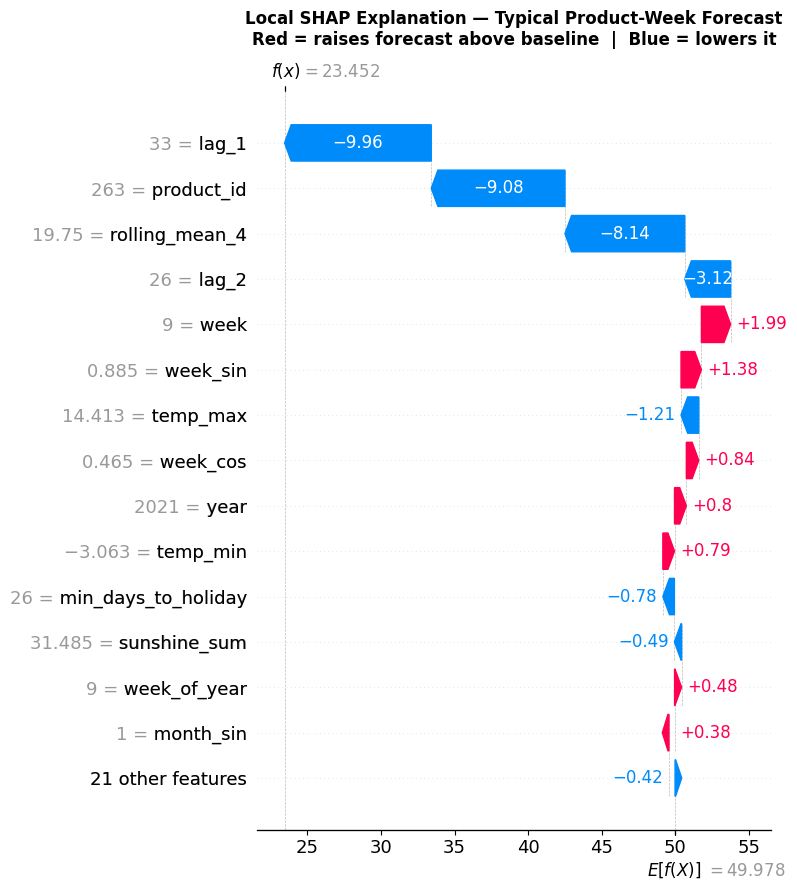

Decomposition for observation 488:
  Baseline E[f(x)]   : 49.98 units
  Sum of SHAP values : -26.53 units
  Final prediction   : 23.45 units


In [13]:

preds_on_sample = baseline + shap_values.values.sum(axis=1)
median_pred     = np.median(preds_on_sample)
closest_idx     = int(np.argmin(np.abs(preds_on_sample - median_pred)))

single_shap = explainer(X_shap.iloc[[closest_idx]])

shap.plots.waterfall(single_shap[0], max_display=15, show=False)
plt.title("Local SHAP Explanation — Typical Product-Week Forecast\n"
          "Red = raises forecast above baseline  |  Blue = lowers it",
          fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Decomposition for observation {closest_idx}:")
print(f"  Baseline E[f(x)]   : {baseline:.2f} units")
print(f"  Sum of SHAP values : {shap_values.values[closest_idx].sum():.2f} units")
print(f"  Final prediction   : {preds_on_sample[closest_idx]:.2f} units")


## 11. SHAP Quality Checks

In [14]:
print("=" * 60)
print("Stability")
print("=" * 60)
shap_run1 = explainer(X_shap.head(50)).values
shap_run2 = explainer(X_shap.head(50)).values
max_stability_err = float(np.max(np.abs(shap_run1 - shap_run2)))

print(f"Max |SHAP_run1 − SHAP_run2| over 50 rows: {max_stability_err:.2e}")
if max_stability_err == 0:
    print("  TreeSHAP is perfectly deterministic (no random sampling).")
    print("  A planner who reloads the dashboard will always see the same")
    print("  explanation for the same forecast — essential for trust.")
else:
    print("  Non-zero — investigate TreeExplainer configuration.")


Stability
Max |SHAP_run1 − SHAP_run2| over 50 rows: 0.00e+00
  TreeSHAP is perfectly deterministic (no random sampling).
  A planner who reloads the dashboard will always see the same
  explanation for the same forecast — essential for trust.


In [15]:
print("=" * 60)
print("Completeness")
print("=" * 60)

shap_reconstructed   = baseline + shap_values.values.sum(axis=1)
model_direct         = model.predict(X_shap)
max_completeness_err = float(np.max(np.abs(shap_reconstructed - model_direct)))

print(f"Max |SHAP_sum − model_pred| over {SHAP_SAMPLE_N} rows: {max_completeness_err:.2e}")
if max_completeness_err < 1e-6:
    print("  Shapley efficiency axiom satisfied.")
    print("  Every prediction is fully decomposed into additive feature")
    print("  contributions — no unexplained residual exists.")
else:
    print("  Non-trivial error — check TreeExplainer setup.")


Completeness
Max |SHAP_sum − model_pred| over 1000 rows: 1.59e-12
  Shapley efficiency axiom satisfied.
  Every prediction is fully decomposed into additive feature
  contributions — no unexplained residual exists.


### Faithfulness Check


FAITHFULNESS ─ feature-ablation test
#removed    wMAPE (SHAP order)    wMAPE (random)
       0                 45.48             45.48
       1                 52.83             46.85
       2                 72.25             46.63
       3                181.13             46.78
       4                180.98             46.72
       5                165.16             46.80
       6                157.99             46.79
       7                162.51             47.62
       8                174.90             47.66
       9                154.01             46.85
      10                152.25             47.01
      11                156.73             46.55
      12                149.43             46.55
      13                150.24             57.22
      14                151.45             59.09
      15                154.68             59.57

Integrated gap (SHAP - random): +1430.3  (positive => SHAP-ranked features matter more, as expected)


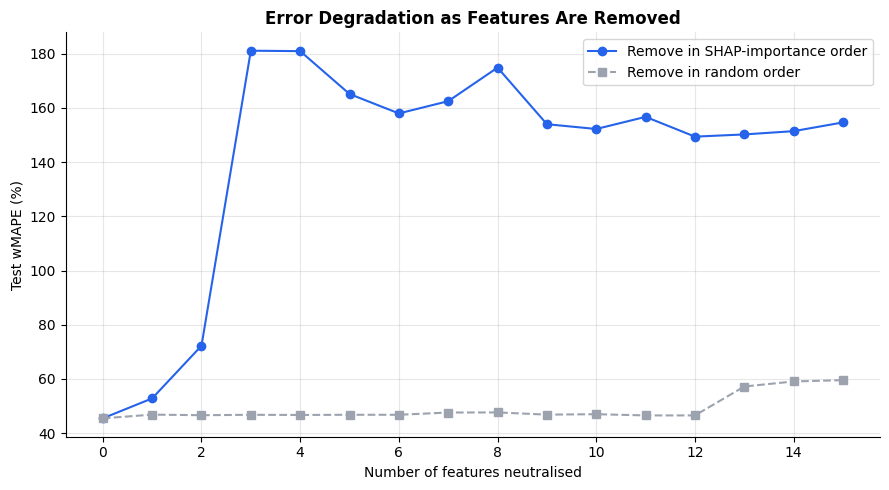

In [16]:
def _neutralised_frame(X, feats_to_remove):
    """Return a copy of X with the given features replaced by a constant."""
    Xc = X.copy()
    for f in feats_to_remove:
        if f in cat_cols:

            mode_value = X_train[f].mode().iloc[0]
            original_categories = X_train[f].cat.categories

            Xc[f] = mode_value

            Xc[f] = pd.Categorical(Xc[f], categories=original_categories)
        else:
            Xc[f] = X_train[f].mean()
    return Xc

shap_order   = mean_shap.index.tolist()
rng_abl      = np.random.RandomState(42)
random_order = shap_order.copy()
rng_abl.shuffle(random_order)

max_remove = min(15, len(shap_order))
steps      = range(0, max_remove + 1)

wmape_shap, wmape_rand = [], []
for k in steps:
    Xs = _neutralised_frame(X_test, shap_order[:k])
    Xr = _neutralised_frame(X_test, random_order[:k])
    wmape_shap.append(wape(y_test.values, np.maximum(model.predict(Xs), 0)))
    wmape_rand.append(wape(y_test.values, np.maximum(model.predict(Xr), 0)))


gap = np.trapz(np.array(wmape_shap) - np.array(wmape_rand), dx=1)

print("=" * 64)
print("FAITHFULNESS ─ feature-ablation test")
print("=" * 64)
print(f"{'#removed':>8}  {'wMAPE (SHAP order)':>20}  {'wMAPE (random)':>16}")
for k in steps:
    print(f"{k:>8}  {wmape_shap[k]:>20.2f}  {wmape_rand[k]:>16.2f}")
print(f"\nIntegrated gap (SHAP - random): {gap:+.1f}  "
      f"(positive => SHAP-ranked features matter more, as expected)")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(steps), wmape_shap, "o-", color="#2563EB",
        label="Remove in SHAP-importance order")
ax.plot(list(steps), wmape_rand, "s--", color="#9CA3AF",
        label="Remove in random order")
ax.set_xlabel("Number of features neutralised")
ax.set_ylabel("Test wMAPE (%)")
ax.set_title("Error Degradation as Features Are Removed", fontweight="bold")
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend()
plt.tight_layout()
plt.savefig("shap_faithfulness.png", dpi=150, bbox_inches="tight")
plt.show()

### Baselines

Explaining: product 164, week 2021-06-28
Forecast f(x) = 28.3 units

--- compared to: Average week ---
  reference value :  50.0 units
  forecast        :  28.3 units
  difference      : -21.6 units
  top 3 drivers of the difference:
      lag_1            -14.05
      lag_2             -2.75
      rolling_mean_8    +2.67


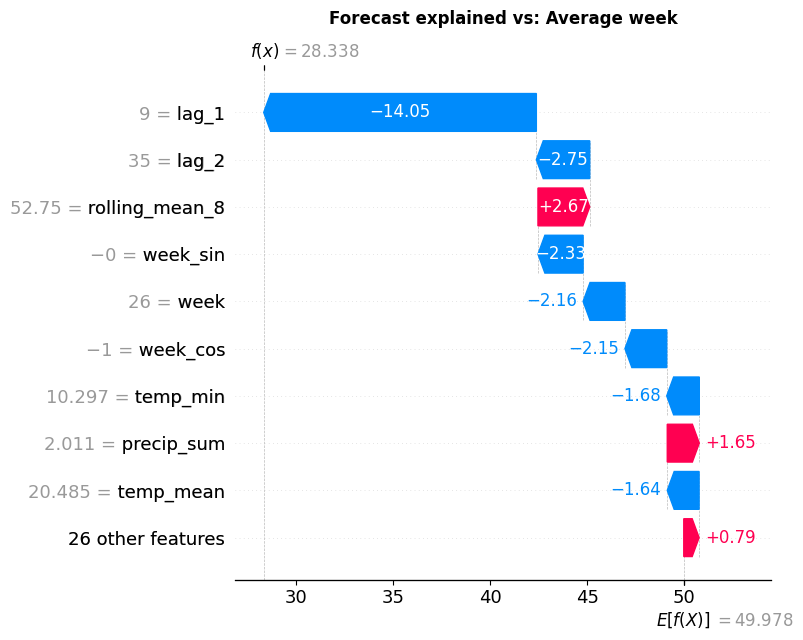


--- compared to: Last week ---
  reference value :  30.0 units
  forecast        :  28.3 units
  difference      :  -1.6 units
  top 3 drivers of the difference:
      lag_1             -3.46
      rolling_mean_4    -3.28
      precip_sum        +1.93


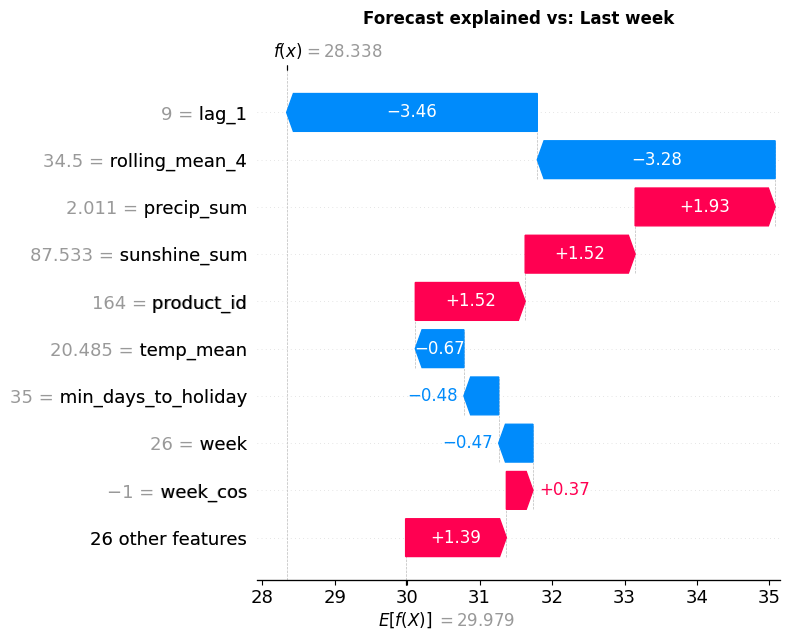


--- compared to: Same week last year ---
  reference value :  44.3 units
  forecast        :  28.3 units
  difference      : -16.0 units
  top 3 drivers of the difference:
      rolling_mean_4   -17.60
      product_id        +2.66
      lag_1             -2.15


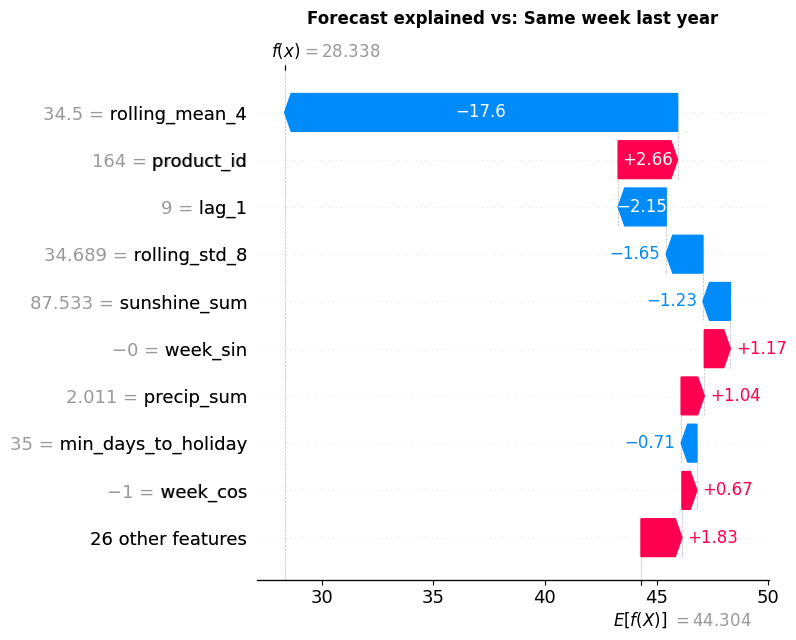


COMPARISON OF BASELINES


,Baseline,Reference,Forecast,Difference,Top driver
0,Average week,50.0,28.3,-21.6,lag_1
1,Last week,30.0,28.3,-1.6,lag_1
2,Same week last year,44.3,28.3,-16.0,rolling_mean_4


In [17]:
focal_pid  = test_df.groupby("product_id").size().sort_values().index[-1]
prod       = df[df["product_id"] == focal_pid].sort_values(date_col).reset_index(drop=True)
focal_i    = prod[prod["year"] == 2021].index[len(prod[prod["year"] == 2021]) // 2]
focal_row  = prod.loc[[focal_i]]
focal_date = focal_row[date_col].iloc[0]

f_focal    = float(model.predict(focal_row[FEATURE_COLS])[0])
shap_focal = explainer(focal_row[FEATURE_COLS]).values[0]

prev_row    = prod.loc[[focal_i - 1]] if focal_i - 1 >= 0 else None
woy         = focal_row["week_of_year"].iloc[0]
lastyr_rows = prod[(prod["year"] == 2020) & (prod["week_of_year"] == woy)]
lastyr_row  = lastyr_rows.iloc[[0]] if len(lastyr_rows) > 0 else None

baselines = [("Average week",        None),
             ("Last week",           prev_row),
             ("Same week last year", lastyr_row)]


print("=" * 64)
print(f"Explaining: product {focal_pid}, week {focal_date.date()}")
print(f"Forecast f(x) = {f_focal:.1f} units")
print("=" * 64)

summary_rows = []
for name, ref_row in baselines:
    if ref_row is None:
        base_value = baseline
        contrib    = pd.Series(shap_focal, index=FEATURE_COLS)
    else:
        base_value = float(model.predict(ref_row[FEATURE_COLS])[0])
        shap_ref   = explainer(ref_row[FEATURE_COLS]).values[0]
        contrib    = pd.Series(shap_focal - shap_ref, index=FEATURE_COLS)

    diff = f_focal - base_value
    top3 = contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(3)

    print(f"\n--- compared to: {name} ---")
    print(f"  reference value : {base_value:5.1f} units")
    print(f"  forecast        : {f_focal:5.1f} units")
    print(f"  difference      : {diff:+5.1f} units")
    print(f"  top 3 drivers of the difference:")
    for feat, val in top3.items():
        print(f"      {feat:<16} {val:+6.2f}")

    summary_rows.append({"Baseline": name,
                         "Reference": round(base_value, 1),
                         "Forecast": round(f_focal, 1),
                         "Difference": round(diff, 1),
                         "Top driver": top3.index[0]})


    expl = shap.Explanation(values=contrib[FEATURE_COLS].values,
                            base_values=base_value,
                            data=focal_row[FEATURE_COLS].iloc[0].values,
                            feature_names=FEATURE_COLS)
    shap.plots.waterfall(expl, max_display=10, show=False)
    plt.title(f"Forecast explained vs: {name}", fontweight="bold", pad=12)
    plt.tight_layout()
    plt.savefig(f"baseline_{name.replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()


print("\n" + "=" * 64)
print("COMPARISON OF BASELINES")
print("=" * 64)
summary_df = pd.DataFrame(summary_rows)
display(summary_df)